In [4]:
import pandas as pd

df = pd.read_csv("data/final_dataset.csv", low_memory=False)

movies = df.drop_duplicates(subset=["movieId"]).copy()
movies = movies.dropna(subset=["release_year"])
movies["release_year"] = movies["release_year"].astype(int)

In [5]:
df["budget"] = df["budget"].replace(0, pd.NA)

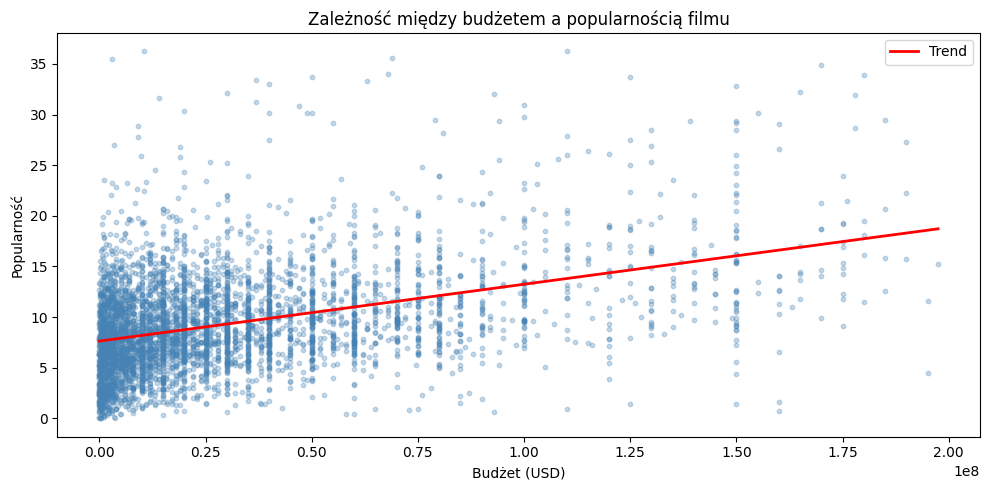

In [6]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = movies.dropna(subset=["budget", "popularity"])
plot_df = plot_df[plot_df["budget"] < plot_df["budget"].quantile(0.99)]
plot_df = plot_df[plot_df["popularity"] < plot_df["popularity"].quantile(0.99)]
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(plot_df["budget"], plot_df["popularity"], alpha=0.3, s=10, color="steelblue")
z = np.polyfit(plot_df["budget"], plot_df["popularity"], 1)
p = np.poly1d(z)
ax.plot(sorted(plot_df["budget"]), p(sorted(plot_df["budget"])), color="red", lw=2, label="Trend")
ax.set_title("Zależność między budżetem a popularnością filmu")
ax.set_xlabel("Budżet (USD)")
ax.set_ylabel("Popularność")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
movies_metadata = pd.read_csv("data/archive/movies_metadata_cleaned.csv", low_memory=False)
movies_metadata["id"] = pd.to_numeric(movies_metadata["id"], errors="coerce").astype("Int64")

movies = movies.merge(
    movies_metadata[["id", "production_countries"]],
    left_on="tmdbId",
    right_on="id",
    how="left"
)

In [9]:
print(movies["production_countries"].dropna().head(10))

0                   united_states_of_america
1                   united_states_of_america
2                   united_states_of_america
3                   united_states_of_america
4                   united_states_of_america
5                   united_states_of_america
6                   united_states_of_america
7                   united_states_of_america
8    united_kingdom united_states_of_america
9            canada united_states_of_america
Name: production_countries, dtype: str


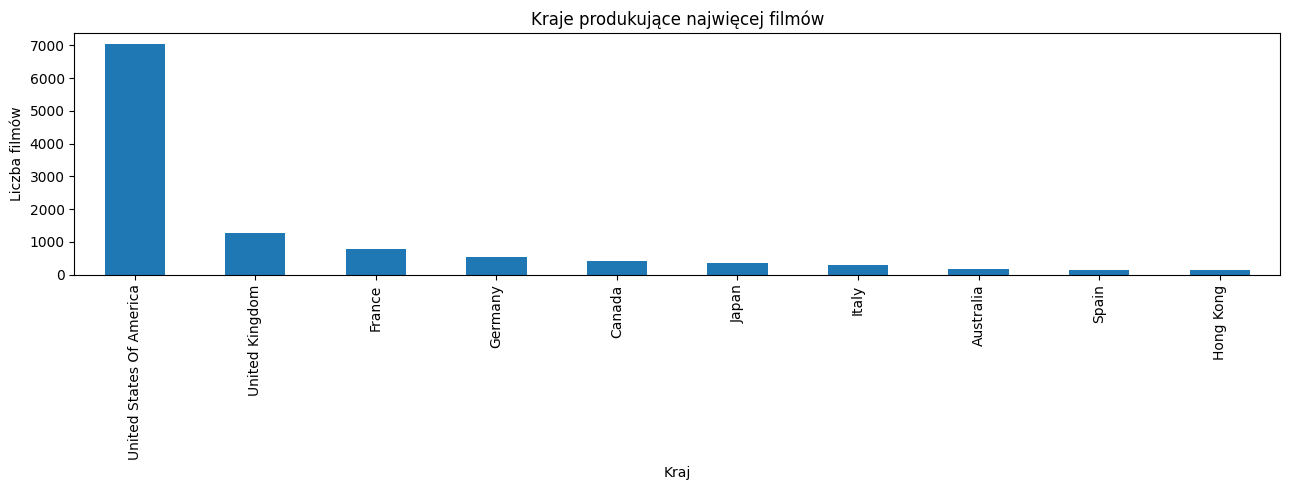

In [15]:
country_df = movies.copy()
country_df["country"] = country_df["production_countries"].str.split()
country_df = country_df.explode("country")
country_df = country_df.dropna(subset=["country"])
country_df["country"] = country_df["country"].str.replace("_", " ").str.title()
top_countries = country_df["country"].value_counts().head(10)
top_countries.plot(kind="bar", figsize=(13, 5))
plt.title("Kraje produkujące najwięcej filmów")
plt.xlabel("Kraj")
plt.ylabel("Liczba filmów")
plt.tight_layout()
plt.show()

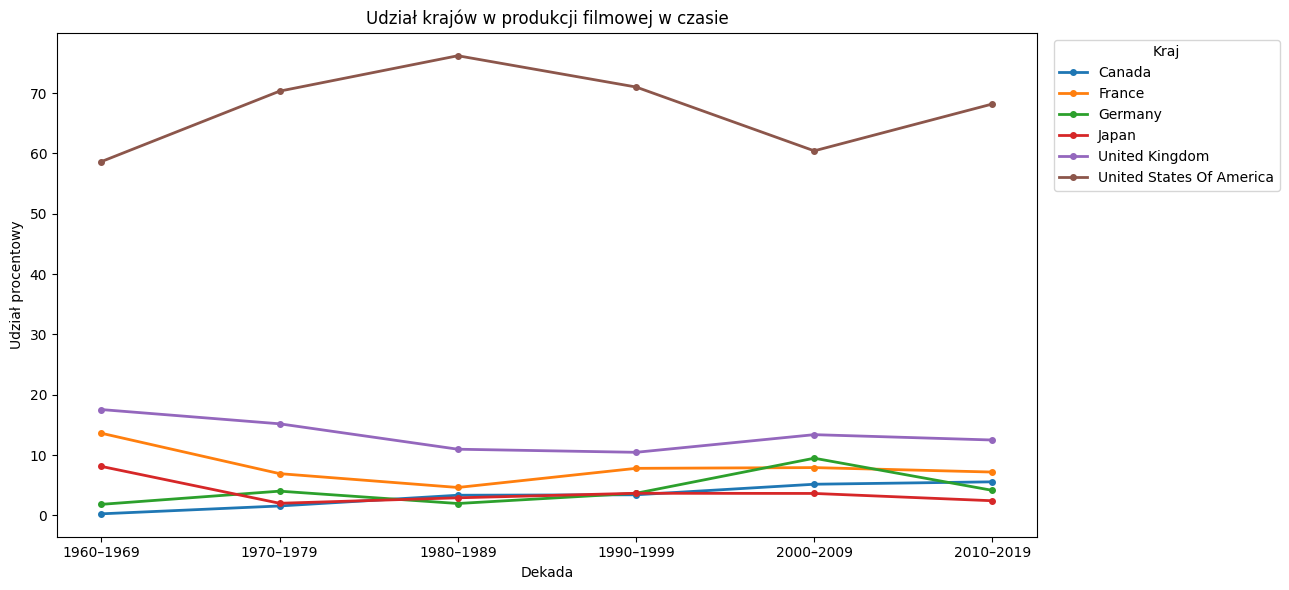

In [21]:
country_df["decade"] = (country_df["release_year"] // 10 * 10).astype(int)
top6 = country_df["country"].value_counts().head(6).index
country_time = country_df[country_df["country"].isin(top6)]
pivot2 = country_time.groupby(["decade", "country"]).size().unstack(fill_value=0)
pivot2 = pivot2.div(pivot2.sum(axis=1), axis=0) * 100
pivot2.index = [f"{int(d)}–{int(d)+9}" for d in pivot2.index]
pivot2 = pivot2[pivot2.index >= "1960–1969"]
pivot2.plot(kind="line", figsize=(13, 6), marker="o", markersize=4, linewidth=2)
plt.title("Udział krajów w produkcji filmowej w czasie")
plt.xlabel("Dekada")
plt.ylabel("Udział procentowy")
plt.legend(title="Kraj", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

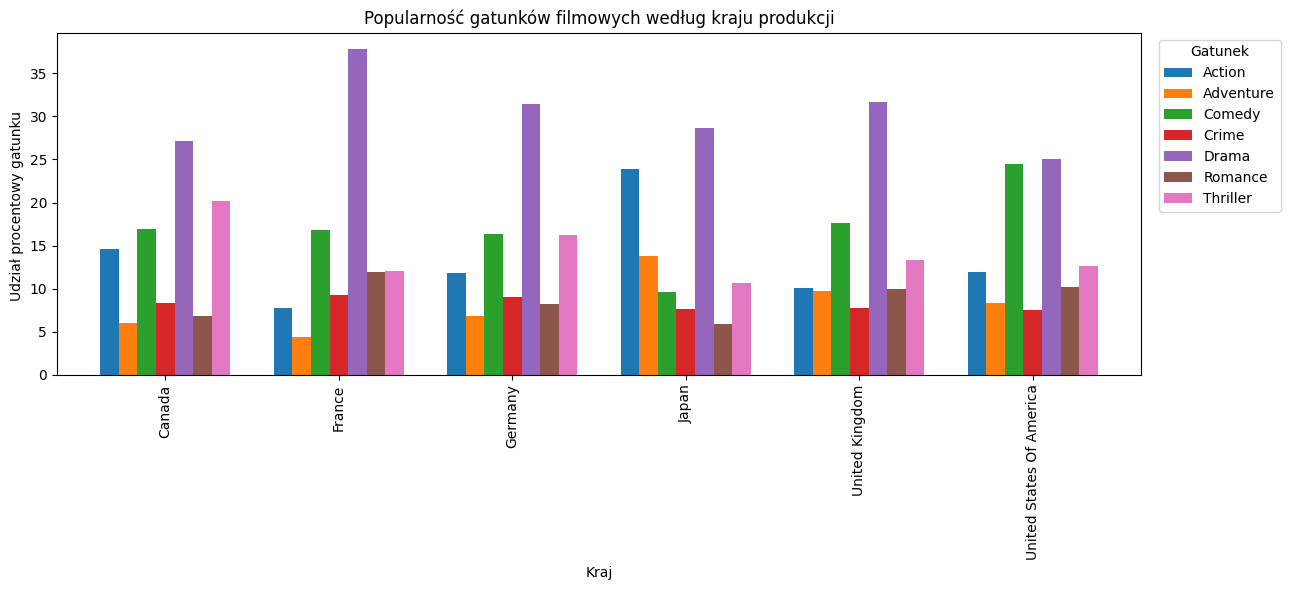

In [22]:
top6 = country_df["country"].value_counts().head(6).index
gdf = country_df[country_df["country"].isin(top6)].copy()
gdf = gdf.assign(genre=gdf["genres_x"].str.split("|")).explode("genre")
gdf = gdf[~gdf["genre"].isin(["(no genres listed)", "IMAX"])]
gdf = gdf[gdf["genre"].isin(gdf["genre"].value_counts().head(7).index)]
pivot = gdf.groupby(["country", "genre"]).size().unstack(fill_value=0)
pivot = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot.plot(kind="bar", figsize=(13, 6), width=0.75)
plt.title("Popularność gatunków filmowych według kraju produkcji")
plt.xlabel("Kraj")
plt.ylabel("Udział procentowy gatunku ")
plt.legend(title="Gatunek", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()